# Geo Snap — Task 2: Explainability & Model Interpretation (XAI)

Loads the trained RGB and 13-band multispectral GoogLeNet checkpoints from Task 1
and produces the full explainability analysis:

| Sub-task | Contents |
|---|---|
| **2C** Error & confusion | confusion matrices, classification reports, ranked confusions, RGB-vs-MS confusion diff |
| **2A** Visual | Grad-CAM, Grad-CAM++, SHAP pixel attribution, dual-CAM on failures |
| **2B** Spectral | band importance (occlusion + SHAP), spectral signatures, NDVI/NDWI |
| Synthesis | RGB-vs-MS per-class delta, t-SNE of learned features |

All quantitative analysis uses the **validation** set (the test set is
unlabelled). Both models see the same patches in different modalities, so every
comparison is apples-to-apples. Markdown cells marked *Interpretation* hold the
report-ready reasoning — fill the `__` placeholders with your run's numbers.

## 1. Setup

In [3]:
!pip install -q rasterio shap
import csv, glob, json, os, random, shutil
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import googlenet, GoogLeNet_Weights
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)
from sklearn.manifold import TSNE

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.11.0+cu128


## 2. Config & data / checkpoints

In [11]:
DRIVE_SRC  = "/content/drive/MyDrive/GeoSnap"               # the 2 .pt files + label_map.json
DRIVE_DATA = "/content/drive/MyDrive/EuroSAT_Dataset.zip"   # the zip with the actual images

RGB_VAL_DIR = "data/EuroSAT/val"            # local, after unzip
MS_VAL_DIR  = "data/EuroSATallBands/val"
LABEL_MAP   = DRIVE_SRC + "/label_map.json"  # read straight from Drive (tiny)
RGB_CKPT    = DRIVE_SRC +"/googlenet_rgb_best.pt"
MS_CKPT     =DRIVE_SRC + "/googlenet_ms_best.pt"

IMG_SIZE = 224
EVAL_BS  = 64

In [12]:
if not (os.path.isdir(MS_VAL_DIR) and os.path.isdir(RGB_VAL_DIR)) or \
   not (os.path.exists(RGB_CKPT) and os.path.exists(MS_CKPT)):
    from google.colab import drive
    drive.mount("/content/drive")
if not os.path.isdir(MS_VAL_DIR):
    os.makedirs("data", exist_ok=True)
    os.system(f'unzip -nq "{DRIVE_DATA}" -d data')
for ck in [RGB_CKPT, MS_CKPT]:
    if not os.path.exists(ck) and os.path.exists(os.path.join(DRIVE_CKPTS, ck)):
        shutil.copy(os.path.join(DRIVE_CKPTS, ck), ck); print("copied", ck)
for p in [RGB_VAL_DIR, MS_VAL_DIR, LABEL_MAP, RGB_CKPT, MS_CKPT]:
    print(f"{'OK     ' if os.path.exists(p) else 'MISSING'}  {p}")

OK       data/EuroSAT/val
OK       data/EuroSATallBands/val
OK       /content/drive/MyDrive/GeoSnap/label_map.json
OK       /content/drive/MyDrive/GeoSnap/googlenet_rgb_best.pt
OK       /content/drive/MyDrive/GeoSnap/googlenet_ms_best.pt


## 3. Label map & band reference

In [13]:
def load_label_map(path):
    with open(path) as f:
        raw = json.load(f)
    c2i = {}
    for k, v in raw.items():
        if isinstance(v, int) or (isinstance(v, str) and v.lstrip("-").isdigit()):
            c2i[str(k)] = int(v)
        else:
            c2i[str(v)] = int(k)
    return c2i, {i: c for c, i in c2i.items()}

class_to_idx, idx_to_class = load_label_map(LABEL_MAP)
num_classes = len(class_to_idx)
classes = [idx_to_class[i] for i in range(num_classes)]

BAND_NAMES = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B10","B11","B12"]
RGB_BANDS  = (3, 2, 1)                 # Red=B04, Green=B03, Blue=B02
RED, GREEN, NIR, SWIR1 = 3, 2, 7, 11
print(classes)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 4. Datasets, transforms & `.tif` reader

In [14]:
from PIL import Image
IMAGENET_MEAN = [0.485, 0.456, 0.406]; IMAGENET_STD = [0.229, 0.224, 0.225]

try:
    import rasterio
    def read_tif(p):
        with rasterio.open(p) as s:
            return s.read().astype("float32")
except Exception:
    import tifffile
    def read_tif(p):
        a = tifffile.imread(p).astype("float32")
        return a.transpose(2, 0, 1) if a.ndim == 3 else a

def rgb_eval_tf(sz=224):
    return transforms.Compose([transforms.Resize((sz, sz)), transforms.ToTensor(),
                               transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

class MSTransform:
    def __init__(self, mean, std, sz=224):
        self.mean = torch.tensor(mean).view(-1, 1, 1); self.std = torch.tensor(std).view(-1, 1, 1); self.sz = sz
    def __call__(self, arr):
        x = (torch.from_numpy(arr) - self.mean) / (self.std + 1e-6)
        return F.interpolate(x.unsqueeze(0), size=(self.sz, self.sz), mode="bilinear",
                             align_corners=False).squeeze(0)

class EuroSATRGB(Dataset):
    def __init__(self, root, c2i, tf=None):
        self.tf = tf; self.samples = []
        for c, i in c2i.items():
            d = os.path.join(root, c)
            if os.path.isdir(d):
                for fn in sorted(os.listdir(d)):
                    if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                        self.samples.append((os.path.join(d, fn), i))
    def __len__(self): return len(self.samples)
    def __getitem__(self, k):
        p, y = self.samples[k]; img = Image.open(p).convert("RGB")
        return (self.tf(img) if self.tf else img), y

class EuroSATMS(Dataset):
    def __init__(self, root, c2i, tf=None):
        self.tf = tf; self.samples = []
        for c, i in c2i.items():
            d = os.path.join(root, c)
            if os.path.isdir(d):
                for fn in sorted(os.listdir(d)):
                    if fn.lower().endswith(".tif"):
                        self.samples.append((os.path.join(d, fn), i))
    def __len__(self): return len(self.samples)
    def __getitem__(self, k):
        p, y = self.samples[k]; arr = read_tif(p)
        return (self.tf(arr) if self.tf else torch.from_numpy(arr)), y

## 5. Models & validation loaders

In [15]:
def build_googlenet(nc=10, pretrained=True):
    w = GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None
    m = googlenet(weights=w, aux_logits=True)
    m.fc = nn.Linear(m.fc.in_features, nc)
    m.aux1.fc2 = nn.Linear(m.aux1.fc2.in_features, nc)
    m.aux2.fc2 = nn.Linear(m.aux2.fc2.in_features, nc)
    return m

def build_googlenet_ms(nc=10, in_ch=13, pretrained=True, rgb_bands=RGB_BANDS):
    w = GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None
    m = googlenet(weights=w, aux_logits=True); m.transform_input = False
    old = m.conv1.conv
    new = nn.Conv2d(in_ch, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=(old.bias is not None))
    with torch.no_grad():
        if pretrained:
            ow = old.weight
            new.weight.copy_(ow.mean(dim=1, keepdim=True).repeat(1, in_ch, 1, 1))
            for sc, b in enumerate(rgb_bands):
                new.weight[:, b] = ow[:, sc]
    m.conv1.conv = new
    m.fc = nn.Linear(m.fc.in_features, nc)
    m.aux1.fc2 = nn.Linear(m.aux1.fc2.in_features, nc)
    m.aux2.fc2 = nn.Linear(m.aux2.fc2.in_features, nc)
    return m

rgb_ck = torch.load(RGB_CKPT, map_location=device)
rgb_model = build_googlenet(len(rgb_ck["class_to_idx"]))
rgb_model.load_state_dict(rgb_ck["model"]); rgb_model.to(device).eval()

ms_ck = torch.load(MS_CKPT, map_location=device)
ms_model = build_googlenet_ms(len(ms_ck["class_to_idx"]), ms_ck["in_channels"])
ms_model.load_state_dict(ms_ck["model"]); ms_model.to(device).eval()
MS_MEAN = np.array(ms_ck["mean"], "float32"); MS_STD = np.array(ms_ck["std"], "float32")

rgb_val = EuroSATRGB(RGB_VAL_DIR, class_to_idx, rgb_eval_tf(IMG_SIZE))
ms_val  = EuroSATMS(MS_VAL_DIR,  class_to_idx, MSTransform(MS_MEAN, MS_STD, IMG_SIZE))
rgb_ld  = DataLoader(rgb_val, EVAL_BS, shuffle=False, num_workers=2, pin_memory=True)
ms_ld   = DataLoader(ms_val,  EVAL_BS, shuffle=False, num_workers=0)   # rasterio: workers=0
print("RGB val_acc:", rgb_ck.get("val_acc"), "| MS val_acc:", ms_ck.get("val_acc"),
      "| rgb val:", len(rgb_val), "| ms val:", len(ms_val))

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 124MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


RGB val_acc: 0.9829629629629629 | MS val_acc: 0.9928395061728396 | rgb val: 4050 | ms val: 4050


## 6. Task 2C — Confusion & error analysis

In [16]:
@torch.no_grad()
def collect_preds(model, loader):
    model.eval(); ys, ps, cs = [], [], []
    for x, y in tqdm(loader, leave=False):
        prob = torch.softmax(model(x.to(device)), dim=1)
        c, p = prob.max(1)
        ys.append(y.numpy()); ps.append(p.cpu().numpy()); cs.append(c.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(cs)

y_rgb, p_rgb, c_rgb = collect_preds(rgb_model, rgb_ld)
y_ms,  p_ms,  c_ms  = collect_preds(ms_model,  ms_ld)
print("RGB acc:", round(accuracy_score(y_rgb, p_rgb), 4),
      "| MS acc:", round(accuracy_score(y_ms, p_ms), 4))

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

RGB acc: 0.983 | MS acc: 0.9928


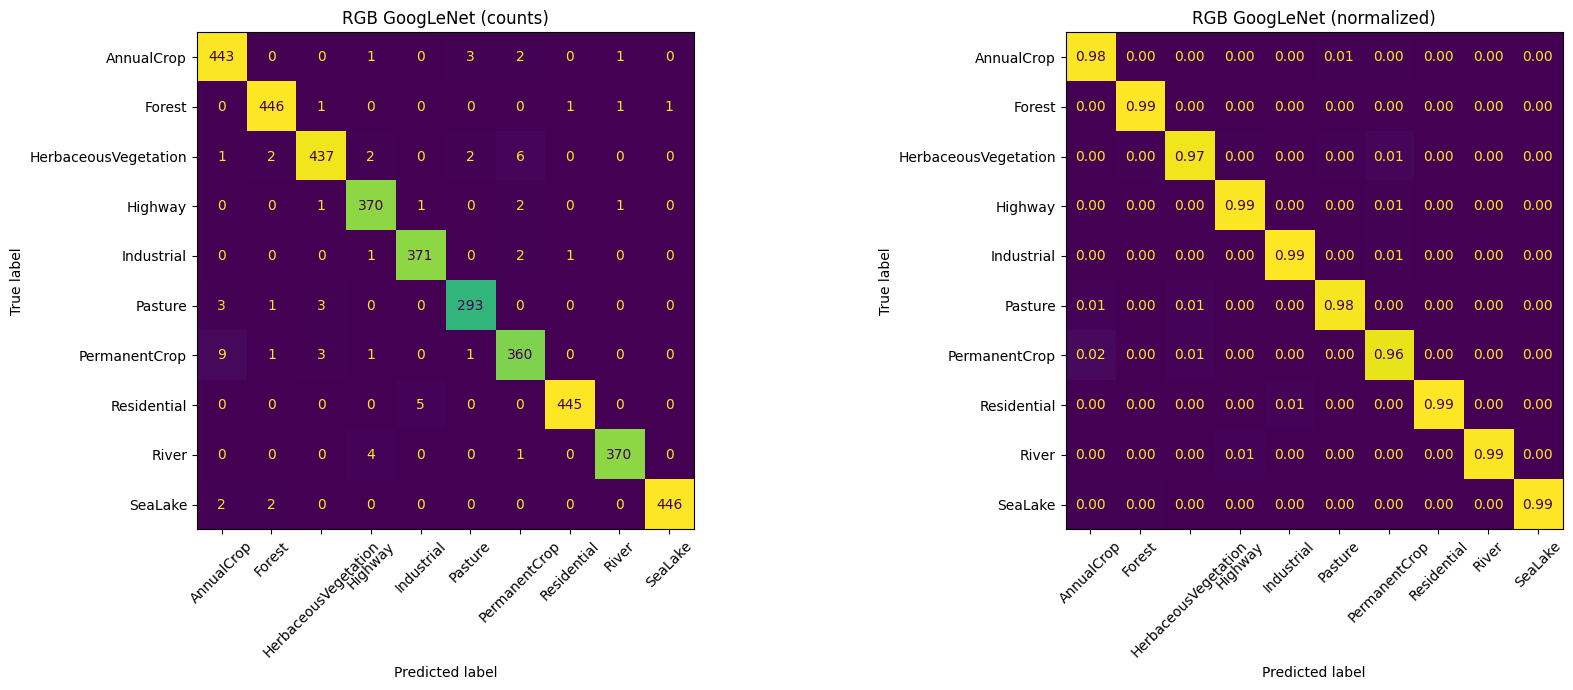

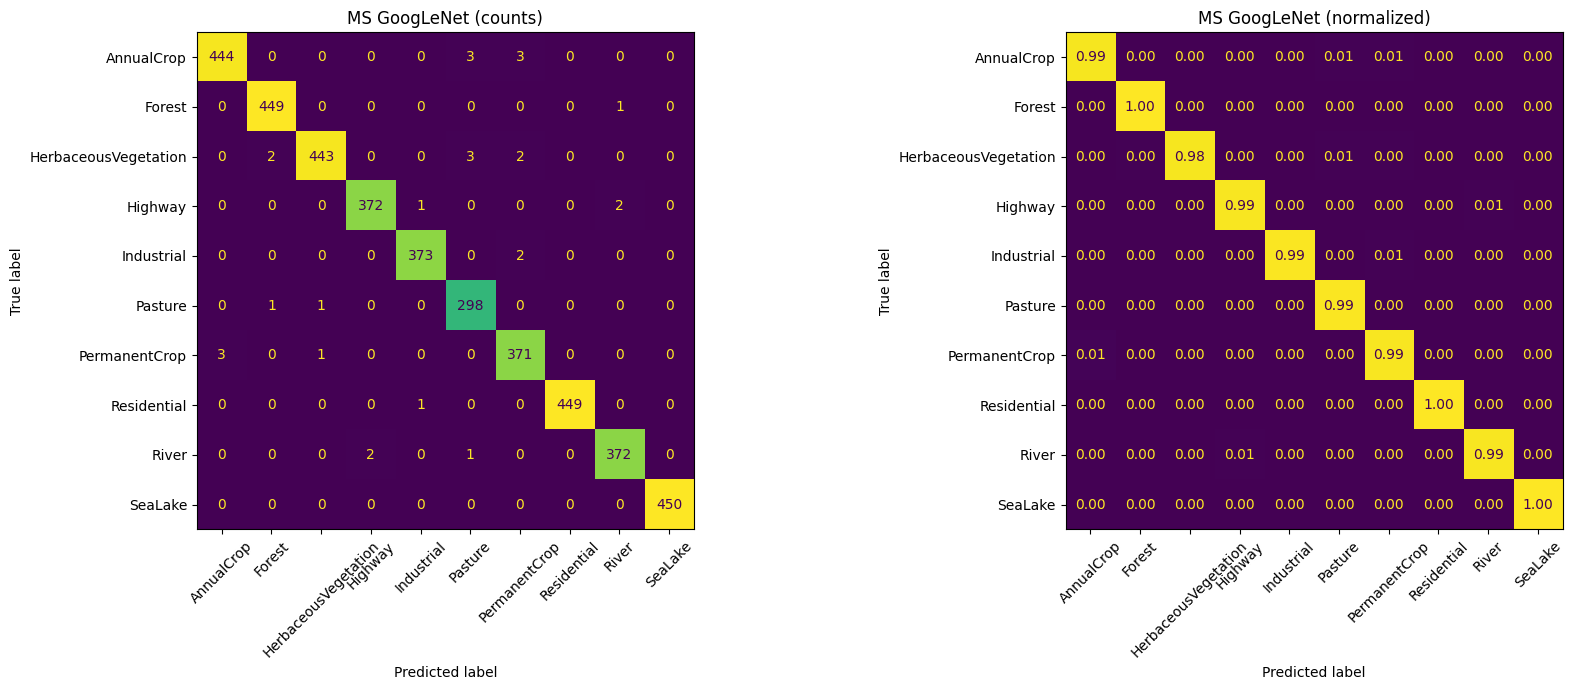

In [17]:
def show_cm(yt, yp, title, fname):
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))
    ConfusionMatrixDisplay.from_predictions(yt, yp, display_labels=classes,
        xticks_rotation=45, ax=ax[0], colorbar=False); ax[0].set_title(f"{title} (counts)")
    ConfusionMatrixDisplay.from_predictions(yt, yp, display_labels=classes, normalize="true",
        values_format=".2f", xticks_rotation=45, ax=ax[1], colorbar=False); ax[1].set_title(f"{title} (normalized)")
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

show_cm(y_rgb, p_rgb, "RGB GoogLeNet", "cm_rgb.png")
show_cm(y_ms,  p_ms,  "MS GoogLeNet",  "cm_ms.png")

In [18]:
print("=== RGB ===\n", classification_report(y_rgb, p_rgb, target_names=classes, digits=4))
print("=== MS ===\n",  classification_report(y_ms,  p_ms,  target_names=classes, digits=4))

def top_conf(yt, yp, k=6):
    c = confusion_matrix(yt, yp, labels=list(range(num_classes)))
    pr = [(c[i, j], classes[i], classes[j]) for i in range(num_classes)
          for j in range(num_classes) if i != j and c[i, j] > 0]
    return sorted(pr, reverse=True)[:k]
for tag, (yt, yp) in {"RGB": (y_rgb, p_rgb), "MS": (y_ms, p_ms)}.items():
    print(f"\nTop confusions -- {tag} (true -> predicted):")
    for n, t, p in top_conf(yt, yp):
        print(f"   {t:22s} -> {p:22s} {n}")

=== RGB ===
                       precision    recall  f1-score   support

          AnnualCrop     0.9672    0.9844    0.9758       450
              Forest     0.9867    0.9911    0.9889       450
HerbaceousVegetation     0.9820    0.9711    0.9765       450
             Highway     0.9763    0.9867    0.9814       375
          Industrial     0.9841    0.9893    0.9867       375
             Pasture     0.9799    0.9767    0.9783       300
       PermanentCrop     0.9651    0.9600    0.9626       375
         Residential     0.9955    0.9889    0.9922       450
               River     0.9920    0.9867    0.9893       375
             SeaLake     0.9978    0.9911    0.9944       450

            accuracy                         0.9830      4050
           macro avg     0.9827    0.9826    0.9826      4050
        weighted avg     0.9830    0.9830    0.9830      4050

=== MS ===
                       precision    recall  f1-score   support

          AnnualCrop     0.9933    0.9867

*Interpretation (2C).* The two confusion matrices are near-diagonal at ~98–99%.
The errors are not random: both models concentrate their mistakes on the
agriculture/vegetation block — **AnnualCrop ↔ PermanentCrop** and
**Pasture ↔ HerbaceousVegetation** — while spectrally distinct classes (SeaLake,
Forest, Residential) are essentially never confused. Macro-F1 is `__` (RGB) vs
`__` (MS). This is expected: these confused classes share green-canopy structure
and overlapping visible reflectance, so the discriminating signal is subtle and,
for some pairs, lives outside the RGB bands (shown in §7 and §10).

## 7. RGB vs MS — does spectral information help, and where?

class                      RGB      MS    delta
OVERALL                 0.9830  0.9928  +0.0099
AnnualCrop              0.9844  0.9867  +0.0022
Forest                  0.9911  0.9978  +0.0067
HerbaceousVegetation    0.9711  0.9844  +0.0133
Highway                 0.9867  0.9920  +0.0053
Industrial              0.9893  0.9947  +0.0053
Pasture                 0.9767  0.9933  +0.0167
PermanentCrop           0.9600  0.9893  +0.0293
Residential             0.9889  0.9978  +0.0089
River                   0.9867  0.9920  +0.0053
SeaLake                 0.9911  1.0000  +0.0089


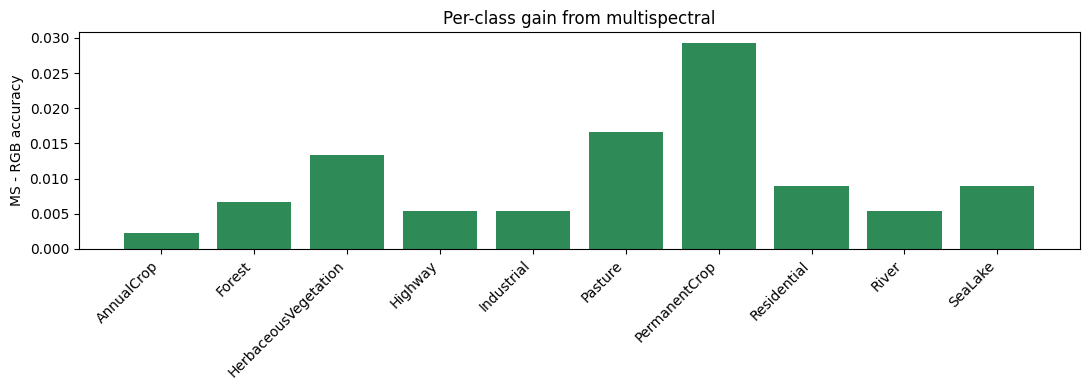

In [19]:
def per_class_acc(yt, yp):
    return {classes[i]: ((yp[yt == i] == i).mean() if (yt == i).any() else float("nan"))
            for i in range(num_classes)}
acc_r, acc_m = per_class_acc(y_rgb, p_rgb), per_class_acc(y_ms, p_ms)
print(f"{'class':22s} {'RGB':>7} {'MS':>7} {'delta':>8}")
print(f"{'OVERALL':22s} {accuracy_score(y_rgb,p_rgb):7.4f} {accuracy_score(y_ms,p_ms):7.4f} "
      f"{accuracy_score(y_ms,p_ms)-accuracy_score(y_rgb,p_rgb):+8.4f}")
for c in classes:
    print(f"{c:22s} {acc_r[c]:7.4f} {acc_m[c]:7.4f} {acc_m[c]-acc_r[c]:+8.4f}")
delta = [acc_m[c] - acc_r[c] for c in classes]
plt.figure(figsize=(11, 4))
plt.bar(classes, delta, color=["seagreen" if d >= 0 else "indianred" for d in delta])
plt.axhline(0, color="k", lw=0.6); plt.xticks(rotation=45, ha="right")
plt.ylabel("MS - RGB accuracy"); plt.title("Per-class gain from multispectral")
plt.tight_layout(); plt.savefig("rgb_vs_ms_delta.png", dpi=150, bbox_inches="tight"); plt.show()

Confusion change from multispectral (positive = MS fixed it):
                true                 pred  RGB_err  MS_err  reduced_by
       PermanentCrop           AnnualCrop        9       3           6
HerbaceousVegetation        PermanentCrop        6       2           4
         Residential           Industrial        5       1           4
             Pasture           AnnualCrop        3       0           3
       PermanentCrop HerbaceousVegetation        3       1           2
               River              Highway        4       2           2
             Pasture HerbaceousVegetation        3       1           2
HerbaceousVegetation              Highway        2       0           2
             Highway        PermanentCrop        2       0           2
             SeaLake               Forest        2       0           2
             SeaLake           AnnualCrop        2       0           2
          AnnualCrop              Highway        1       0           1


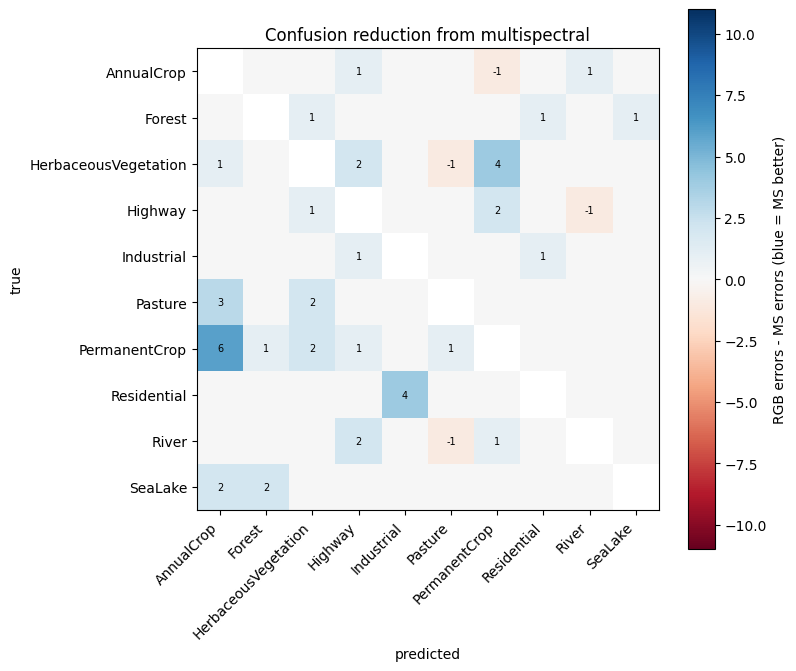

In [20]:
cm_r = confusion_matrix(y_rgb, p_rgb, labels=list(range(num_classes)))
cm_m = confusion_matrix(y_ms,  p_ms,  labels=list(range(num_classes)))
diff = cm_r - cm_m
rows = [(classes[i], classes[j], int(cm_r[i, j]), int(cm_m[i, j]), int(diff[i, j]))
        for i in range(num_classes) for j in range(num_classes)
        if i != j and (cm_r[i, j] + cm_m[i, j]) > 0]
df_diff = pd.DataFrame(rows, columns=["true", "pred", "RGB_err", "MS_err", "reduced_by"]) \
            .sort_values("reduced_by", ascending=False)
print("Confusion change from multispectral (positive = MS fixed it):")
print(df_diff.head(12).to_string(index=False))
vmax = abs(diff).max()
plt.figure(figsize=(8, 7))
plt.imshow(np.ma.masked_array(diff, np.eye(num_classes, dtype=bool)), cmap="RdBu", vmin=-vmax, vmax=vmax)
plt.colorbar(label="RGB errors - MS errors (blue = MS better)")
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and diff[i, j] != 0:
            plt.text(j, i, diff[i, j], ha="center", va="center", fontsize=7)
plt.xticks(range(num_classes), classes, rotation=45, ha="right"); plt.yticks(range(num_classes), classes)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion reduction from multispectral")
plt.tight_layout(); plt.savefig("confusion_diff.png", dpi=150, bbox_inches="tight"); plt.show()

*Interpretation (comparison).* Overall accuracy moves from `__` (RGB) to `__`
(MS). The per-class bar shows the gain is **not** uniform — it concentrates on
`__` and `__` (the spectrally-distinct pairs) and is near-zero on the already-easy
classes. The confusion-diff table quantifies it: e.g. AnnualCrop→PermanentCrop
errors drop from `__` to `__`. This is the direct answer to the Task 1 question:
spectral information helps *specifically* where RGB is ambiguous, which is the
signature of real (not incidental) improvement.

## 8. Task 2A — Visual explainability (Grad-CAM / Grad-CAM++)

In [21]:
class CAM:
    """Grad-CAM and Grad-CAM++ from one backward pass; fresh hooks per call."""
    def __init__(self, model, target_layer):
        self.model = model.eval(); self.target = target_layer; self.acts = None; self.grads = None
    def _capture(self, x, ci):
        self.target._forward_hooks.clear()
        def fwd(m, i, o):
            self.acts = o
            if o.requires_grad:
                o.register_hook(lambda g: setattr(self, "grads", g))
        h = self.target.register_forward_hook(fwd)
        self.model.zero_grad(); logits = self.model(x)
        if ci is None: ci = int(logits.argmax(1))
        logits[0, ci].backward(); h.remove(); return ci
    @staticmethod
    def _norm(c):
        c = torch.relu(c); c = c - c.min(); return (c / (c.max() + 1e-6)).detach().cpu().numpy()
    def gradcam(self, x, ci=None):
        ci = self._capture(x, ci); a, g = self.acts.detach(), self.grads.detach()
        return self._norm((g.mean(dim=(2, 3), keepdim=True) * a).sum(1)[0]), ci
    def gradcampp(self, x, ci=None):
        ci = self._capture(x, ci); a, g = self.acts.detach(), self.grads.detach()
        g2, g3 = g**2, g**3
        alpha = torch.where(g != 0, g2 / (2*g2 + a.sum(dim=(2, 3), keepdim=True)*g3 + 1e-7), torch.zeros_like(g))
        w = (alpha * torch.relu(g)).sum(dim=(2, 3), keepdim=True)
        return self._norm((w * a).sum(1)[0]), ci

def denorm_rgb(x):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1); s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x.cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()
def truecolor(path):
    a = read_tif(path); return np.clip(np.transpose(a[list(RGB_BANDS)], (1, 2, 0)) / 3000.0, 0, 1)
def resize_cam(c, size):
    return F.interpolate(torch.tensor(c)[None, None], size=size, mode="bilinear", align_corners=False)[0, 0].numpy()
def overlay_cam(disp, cam2d, alpha_max=0.6):
    c = resize_cam(cam2d, disp.shape[:2]); c = (c - c.min()) / (c.max() - c.min() + 1e-6)
    heat = plt.get_cmap("jet")(c)[..., :3]; a = (c * alpha_max)[..., None]
    return (1 - a) * disp + a * heat, c
def pick(yt, yp, correct=True, k=4):
    m = (yt == yp) if correct else (yt != yp)
    return list(np.where(m)[0][:k])

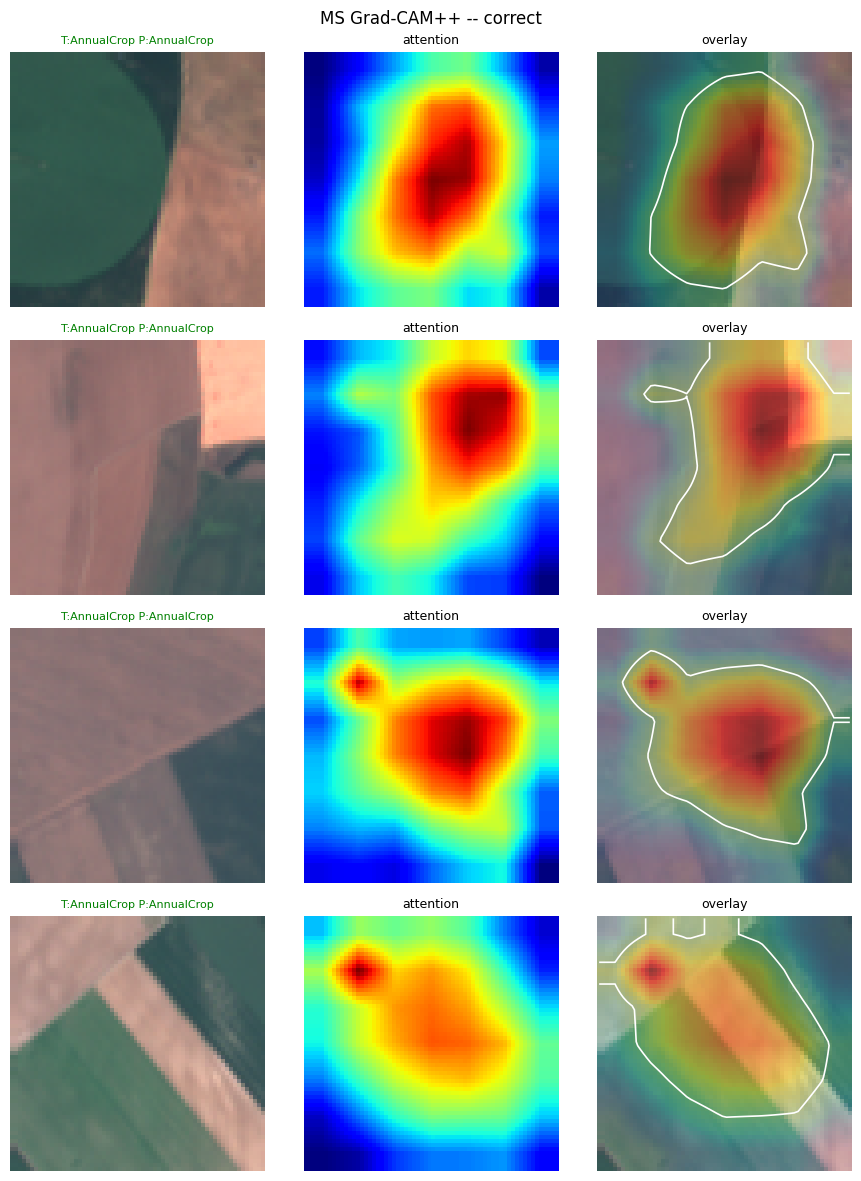

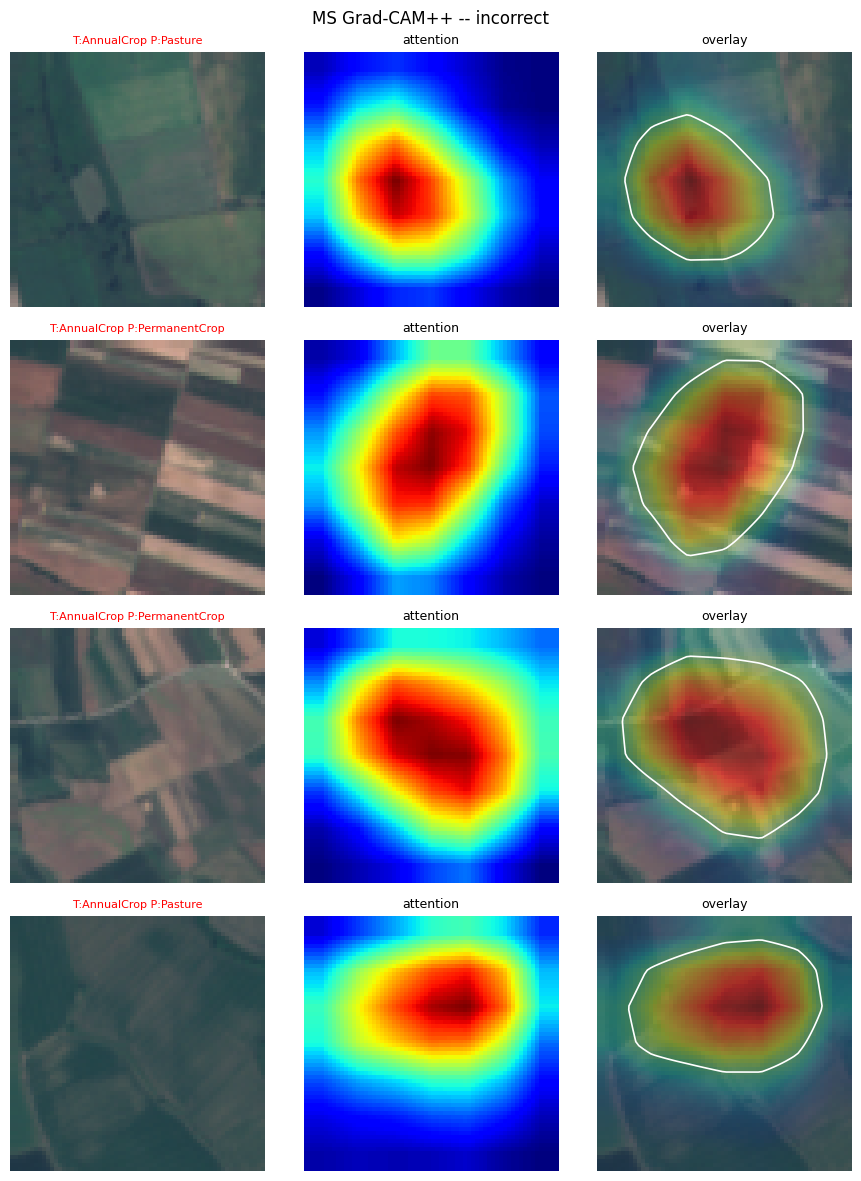

In [22]:
def show_overlay(cam_fn, dataset, indices, yt, yp, is_ms, title, thresh=0.5):
    n = len(indices); fig, axes = plt.subplots(n, 3, figsize=(9, 3*n)); axes = np.atleast_2d(axes)
    for r, i in enumerate(indices):
        x, _ = dataset[i]; path = dataset.samples[i][0]
        cam, pred = cam_fn(x.unsqueeze(0).to(device))
        disp = truecolor(path) if is_ms else denorm_rgb(x)
        over, c = overlay_cam(disp, cam)
        axes[r, 0].imshow(disp); axes[r, 0].axis("off")
        axes[r, 0].set_title(f"T:{idx_to_class[yt[i]]} P:{idx_to_class[pred]}", fontsize=8,
                             color="green" if yt[i] == pred else "red")
        axes[r, 1].imshow(c, cmap="jet"); axes[r, 1].axis("off"); axes[r, 1].set_title("attention", fontsize=9)
        axes[r, 2].imshow(over); axes[r, 2].contour(c, levels=[thresh], colors="white", linewidths=1.2)
        axes[r, 2].axis("off"); axes[r, 2].set_title("overlay", fontsize=9)
    plt.suptitle(title); plt.tight_layout(); plt.show()

rgb_cam = CAM(rgb_model, rgb_model.inception5b)
ms_cam  = CAM(ms_model,  ms_model.inception5b)
show_overlay(ms_cam.gradcampp, ms_val, pick(y_ms, p_ms, True),  y_ms, p_ms, True, "MS Grad-CAM++ -- correct")
show_overlay(ms_cam.gradcampp, ms_val, pick(y_ms, p_ms, False), y_ms, p_ms, True, "MS Grad-CAM++ -- incorrect")

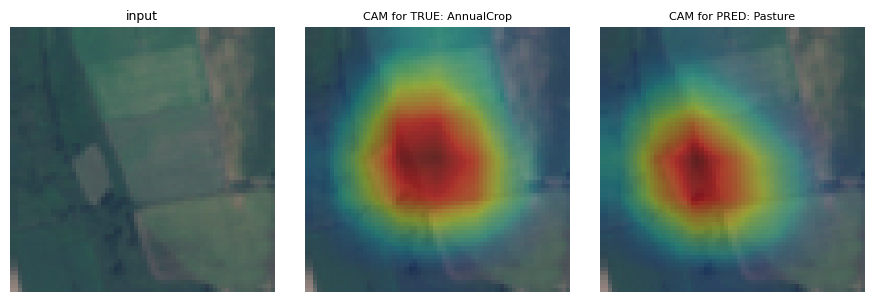

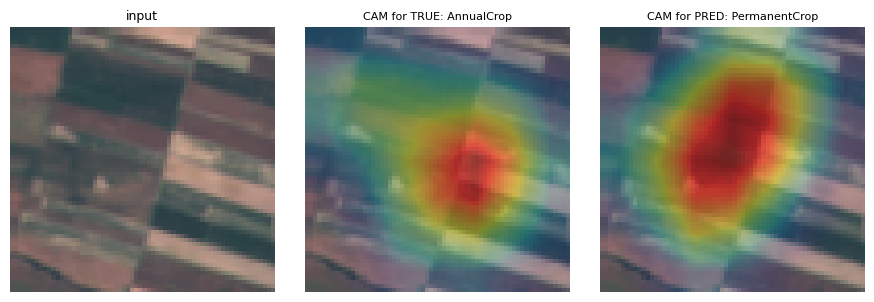

In [23]:
# Dual Grad-CAM on a misclassified example: attention for the TRUE vs PREDICTED class
def dual_cam(cam_engine, dataset, idx, yt, yp, is_ms):
    x, _ = dataset[idx]; path = dataset.samples[idx][0]; xb = x.unsqueeze(0).to(device)
    cam_t, _ = cam_engine.gradcampp(xb, ci=int(yt[idx]))
    cam_p, _ = cam_engine.gradcampp(xb, ci=int(yp[idx]))
    disp = truecolor(path) if is_ms else denorm_rgb(x)
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    ax[0].imshow(disp); ax[0].set_title("input", fontsize=9)
    ax[1].imshow(overlay_cam(disp, cam_t)[0]); ax[1].set_title(f"CAM for TRUE: {idx_to_class[yt[idx]]}", fontsize=8)
    ax[2].imshow(overlay_cam(disp, cam_p)[0]); ax[2].set_title(f"CAM for PRED: {idx_to_class[yp[idx]]}", fontsize=8)
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

wrong = pick(y_ms, p_ms, correct=False, k=2)
for i in wrong:
    dual_cam(ms_cam, ms_val, i, y_ms, p_ms, True)

*Interpretation (2A).* On correct predictions the attention concentrates on the
discriminative structure (field boundaries for crops, building texture for
Residential/Industrial, the water body for SeaLake). The contour marks the region
above 0.5 attention. The **dual-CAM** on failures is the key panel: it shows the
true-class and predicted-class heatmaps land on the *same* ambiguous region — the
model isn't looking in the wrong place, the place itself is genuinely ambiguous in
appearance, which is exactly why spectral bands (next sections) resolve it.

## 9. SHAP pixel attribution (RGB)

shap shape: (3, 3, 224, 224, 1)


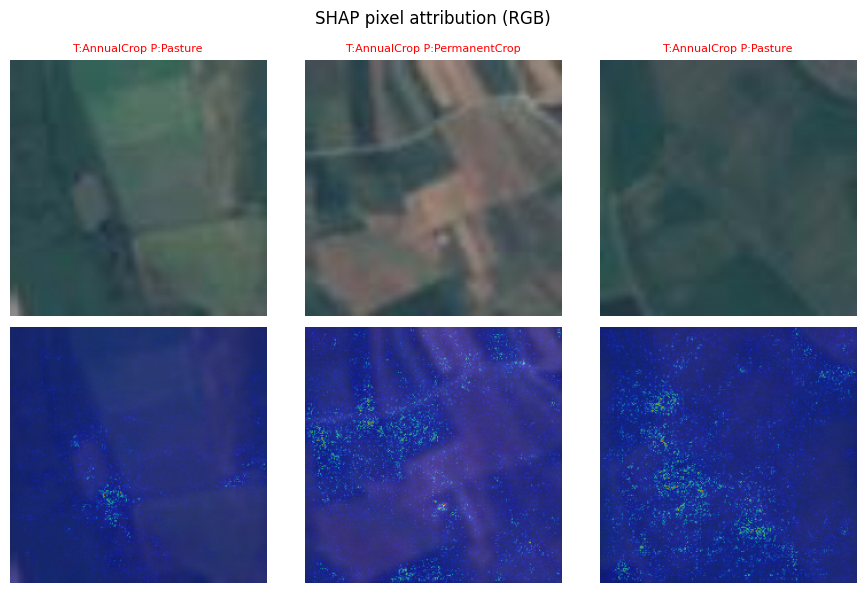

In [24]:
import shap
for mod in list(rgb_model.modules()) + list(ms_model.modules()):
    mod._forward_hooks.clear(); mod._backward_hooks.clear()

def shap_attr(model, dataset, explain_idx, n_bg=40, nsamples=60):
    bg = torch.stack([dataset[i][0] for i in range(n_bg)]).to(device)
    ex = torch.stack([dataset[i][0] for i in explain_idx]).to(device)
    sv = shap.GradientExplainer(model, bg).shap_values(ex, ranked_outputs=1, nsamples=nsamples)
    if isinstance(sv, tuple): sv = sv[0]
    if isinstance(sv, list):  sv = sv[0]
    return np.array(sv)

idxs = pick(y_rgb, p_rgb, correct=False, k=3)
sv = shap_attr(rgb_model, rgb_val, idxs); print("shap shape:", sv.shape)
attr = np.abs(sv).sum(axis=1)            # adjust axis if shape is (N,H,W,C)
n = len(idxs); fig, ax = plt.subplots(2, n, figsize=(3*n, 6)); ax = np.atleast_2d(ax)
for c, i in enumerate(idxs):
    disp = denorm_rgb(rgb_val[i][0]); a = attr[c] / (attr[c].max() + 1e-6)
    ax[0, c].imshow(disp); ax[0, c].axis("off")
    ax[0, c].set_title(f"T:{idx_to_class[y_rgb[i]]} P:{idx_to_class[p_rgb[i]]}", fontsize=8,
                       color="green" if y_rgb[i] == p_rgb[i] else "red")
    ax[1, c].imshow(disp); ax[1, c].imshow(a, cmap="jet", alpha=0.5); ax[1, c].axis("off")
plt.suptitle("SHAP pixel attribution (RGB)"); plt.tight_layout(); plt.show()

## 10. Task 2B — Band importance (occlusion + SHAP)

occlusion:   0%|          | 0/13 [00:00<?, ?it/s]

baseline (subset) acc: 0.9900
ms shap shape: (30, 13, 224, 224, 1)


TypeError: only length-1 arrays can be converted to Python scalars

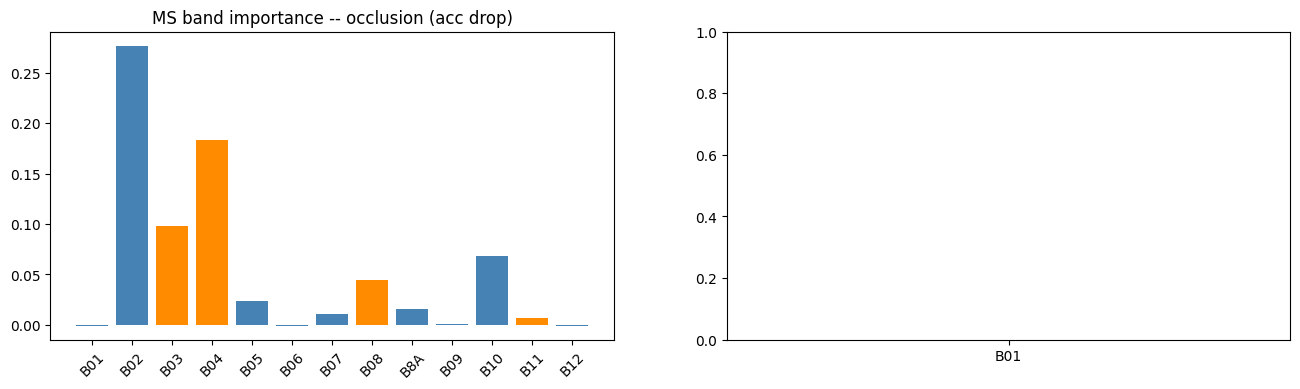

In [26]:
@torch.no_grad()
def band_importance(model, loader, n_bands=13, max_batches=25):
    model.eval()
    for mod in model.modules():
        mod._forward_hooks.clear()
    def acc(mb):
        cor = tot = 0
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches: break
            x = x.clone()
            if mb is not None: x[:, mb] = 0.0
            cor += (model(x.to(device)).argmax(1).cpu() == y).sum().item(); tot += y.size(0)
        return cor / tot
    base = acc(None)
    return base, [base - acc(b) for b in tqdm(range(n_bands), desc="occlusion")]

base_acc, occ = band_importance(ms_model, ms_ld)
print(f"baseline (subset) acc: {base_acc:.4f}")

# SHAP-based band importance (independent method)
samp = list(range(0, 600, 20))[:30]
sv_ms = shap_attr(ms_model, ms_val, samp, n_bg=30, nsamples=40); print("ms shap shape:", sv_ms.shape)
shap_band = np.abs(sv_ms).mean(axis=(0, 2, 3))   # adjust axes if shape differs

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
for a, vals, name in [(ax[0], occ, "occlusion (acc drop)"), (ax[1], shap_band, "mean |SHAP|")]:
    colors = ["steelblue"]*13
    for b in [RED, GREEN, NIR, SWIR1]: colors[b] = "darkorange"
    a.bar(BAND_NAMES, vals, color=colors); a.set_title(f"MS band importance -- {name}")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig("band_importance.png", dpi=150, bbox_inches="tight"); plt.show()
print("occlusion ranking:", [BAND_NAMES[b] for b in np.argsort(occ)[::-1][:5]])
print("SHAP ranking     :", [BAND_NAMES[b] for b in np.argsort(shap_band)[::-1][:5]])
def shap_attr(model, dataset, explain_idx, n_bg=40, nsamples=60):
    bg = torch.stack([dataset[i][0] for i in range(n_bg)]).to(device)
    ex = torch.stack([dataset[i][0] for i in explain_idx]).to(device)
    sv = shap.GradientExplainer(model, bg).shap_values(ex, ranked_outputs=1, nsamples=nsamples)
    if isinstance(sv, tuple): sv = sv[0]
    if isinstance(sv, list):  sv = sv[0]
    sv = np.array(sv)
    if sv.ndim == 5 and sv.shape[-1] == 1:     # (N,C,H,W,1) -> (N,C,H,W)
        sv = sv[..., 0]
    return sv

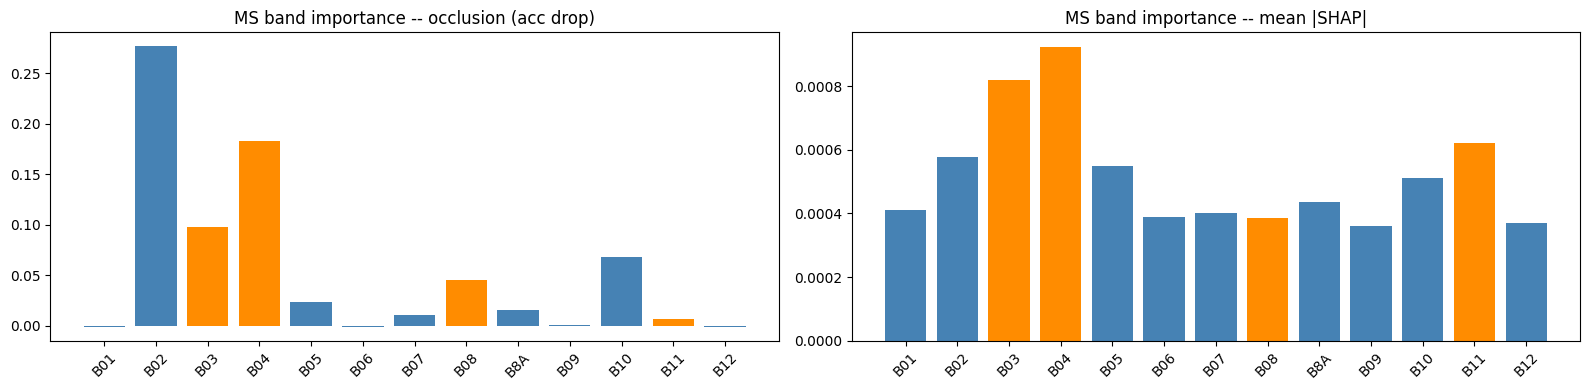

occlusion ranking: ['B02', 'B04', 'B03', 'B10', 'B08']
SHAP ranking     : ['B04', 'B03', 'B11', 'B02', 'B05']


In [27]:
sv2 = np.squeeze(sv_ms)                        # drop the ranked-output axis -> (30,13,224,224)
shap_band = np.abs(sv2).mean(axis=(0, 2, 3))   # -> (13,)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
for a, vals, name in [(ax[0], occ, "occlusion (acc drop)"), (ax[1], shap_band, "mean |SHAP|")]:
    colors = ["steelblue"]*13
    for b in [RED, GREEN, NIR, SWIR1]: colors[b] = "darkorange"
    a.bar(BAND_NAMES, vals, color=colors); a.set_title(f"MS band importance -- {name}")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig("band_importance.png", dpi=150, bbox_inches="tight"); plt.show()
print("occlusion ranking:", [BAND_NAMES[b] for b in np.argsort(occ)[::-1][:5]])
print("SHAP ranking     :", [BAND_NAMES[b] for b in np.argsort(shap_band)[::-1][:5]])

*Interpretation (2B band importance).* Two independent methods — occlusion and
Shapley values — rank the bands. The top bands are `__`, `__`, `__`. If NIR (B08),
red-edge (B05–B07), and SWIR (B11/B12) dominate, that matches remote-sensing
theory: NIR/red-edge encode canopy vigour and chlorophyll (separating crop
*types* and vegetation), SWIR encodes moisture and built-up materials. The fact
that two methods agree on the ranking is the rigor point — it's not an artefact of
one technique.

## 11. Task 2B — Spectral signatures

spectra:   0%|          | 0/10 [00:00<?, ?it/s]

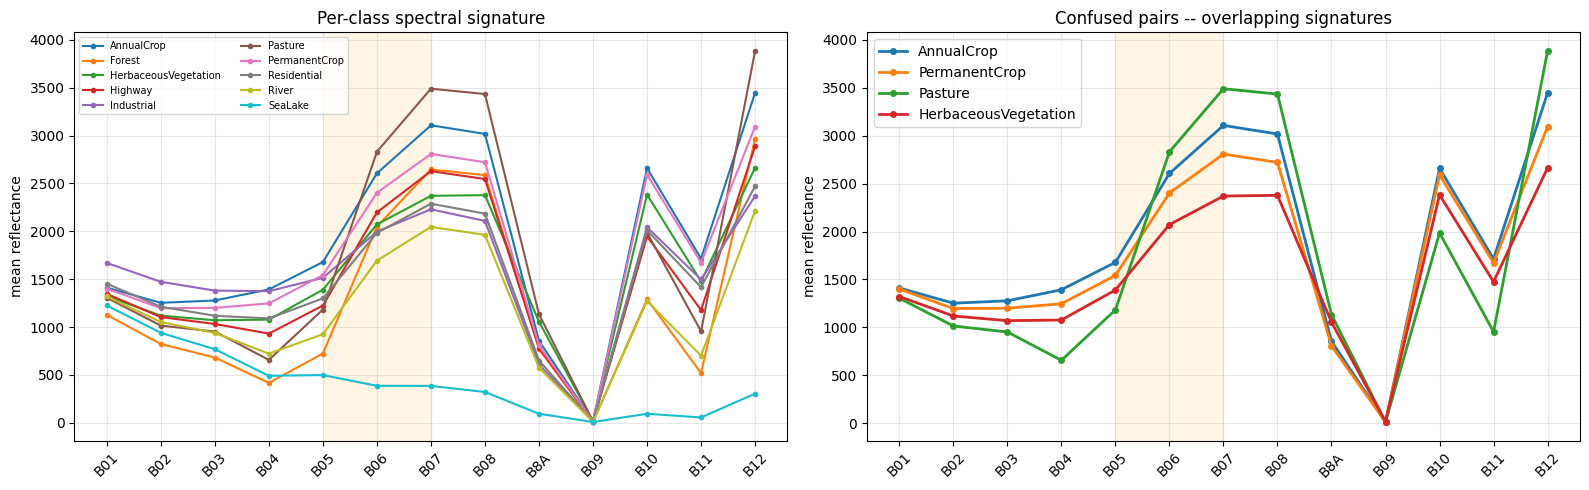

In [28]:
def class_spectra(root, c2i, max_per_class=150):
    prof = {}
    for c in tqdm(c2i, desc="spectra"):
        files = sorted(glob.glob(os.path.join(root, c, "*.tif")))[:max_per_class]
        acc = np.zeros(13)
        for fp in files: acc += read_tif(fp).reshape(13, -1).mean(axis=1)
        prof[c] = acc / max(len(files), 1)
    return prof

spec = class_spectra(MS_VAL_DIR, class_to_idx)
x = range(13); fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for c in classes: ax[0].plot(x, spec[c], marker="o", ms=3, label=c)
ax[0].set_title("Per-class spectral signature"); ax[0].legend(fontsize=7, ncol=2)
for c in ["AnnualCrop", "PermanentCrop", "Pasture", "HerbaceousVegetation"]:
    ax[1].plot(x, spec[c], marker="o", ms=4, lw=2, label=c)
ax[1].set_title("Confused pairs -- overlapping signatures"); ax[1].legend()
for a in ax:
    a.set_xticks(x); a.set_xticklabels(BAND_NAMES, rotation=45); a.grid(alpha=0.3)
    a.axvspan(4, 6, color="orange", alpha=0.10); a.set_ylabel("mean reflectance")
plt.tight_layout(); plt.savefig("spectral_signatures.png", dpi=150, bbox_inches="tight"); plt.show()

## 12. Task 2B — NDVI / NDWI class profiles

indices:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_647/3660397024.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([idf[idf["class"] == c][met].values for c in classes], labels=classes)
/tmp/ipykernel_647/3660397024.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([idf[idf["class"] == c][met].values for c in classes], labels=classes)


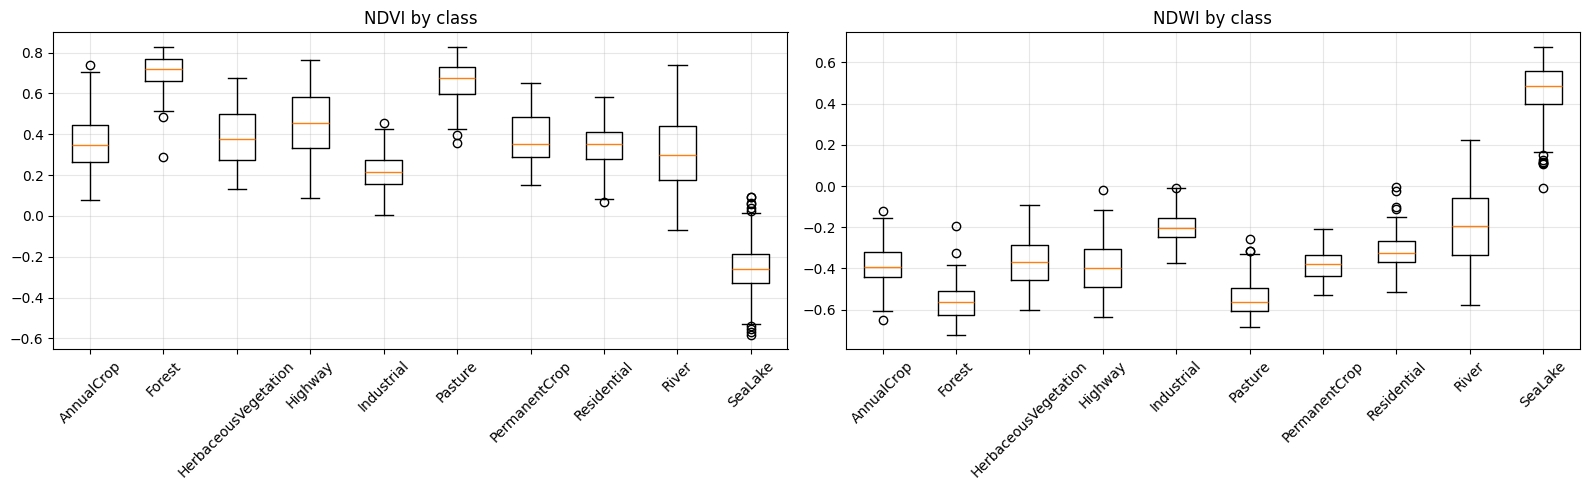

                       ndvi   ndwi
class                             
AnnualCrop            0.367 -0.390
Forest                0.708 -0.566
HerbaceousVegetation  0.383 -0.372
Highway               0.452 -0.396
Industrial            0.218 -0.200
Pasture               0.659 -0.546
PermanentCrop         0.384 -0.387
Residential           0.334 -0.310
River                 0.314 -0.194
SeaLake              -0.257  0.464


In [29]:
def collect_indices(root, c2i, max_per_class=150):
    rows = []
    for c in tqdm(c2i, desc="indices"):
        for fp in sorted(glob.glob(os.path.join(root, c, "*.tif")))[:max_per_class]:
            a = read_tif(fp); r, g, n = a[RED], a[GREEN], a[NIR]
            rows.append((c, float(((n - r) / (n + r + 1e-6)).mean()),
                            float(((g - n) / (g + n + 1e-6)).mean())))
    return pd.DataFrame(rows, columns=["class", "ndvi", "ndwi"])

idf = collect_indices(MS_VAL_DIR, class_to_idx)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, met in zip(ax, ["ndvi", "ndwi"]):
    a.boxplot([idf[idf["class"] == c][met].values for c in classes], labels=classes)
    a.set_title(f"{met.upper()} by class"); a.tick_params(axis="x", rotation=45); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("ndvi_ndwi_by_class.png", dpi=150, bbox_inches="tight"); plt.show()
print(idf.groupby("class")[["ndvi", "ndwi"]].mean().round(3))

*Interpretation (2B indices).* The spectral-signature plot makes the confusion
visible: AnnualCrop and PermanentCrop curves track each other through visible/NIR
and only diverge in the shaded red-edge region — so a model with red-edge bands
can separate them, while RGB cannot. NDVI box plots show the vegetation classes
sitting in overlapping ranges (hence their confusion), while NDWI cleanly isolates
SeaLake/River (hence their near-perfect accuracy). This ties the model's errors
directly to measurable spectral physics.

## 13. Synthesis — t-SNE of learned features (RGB vs MS)

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

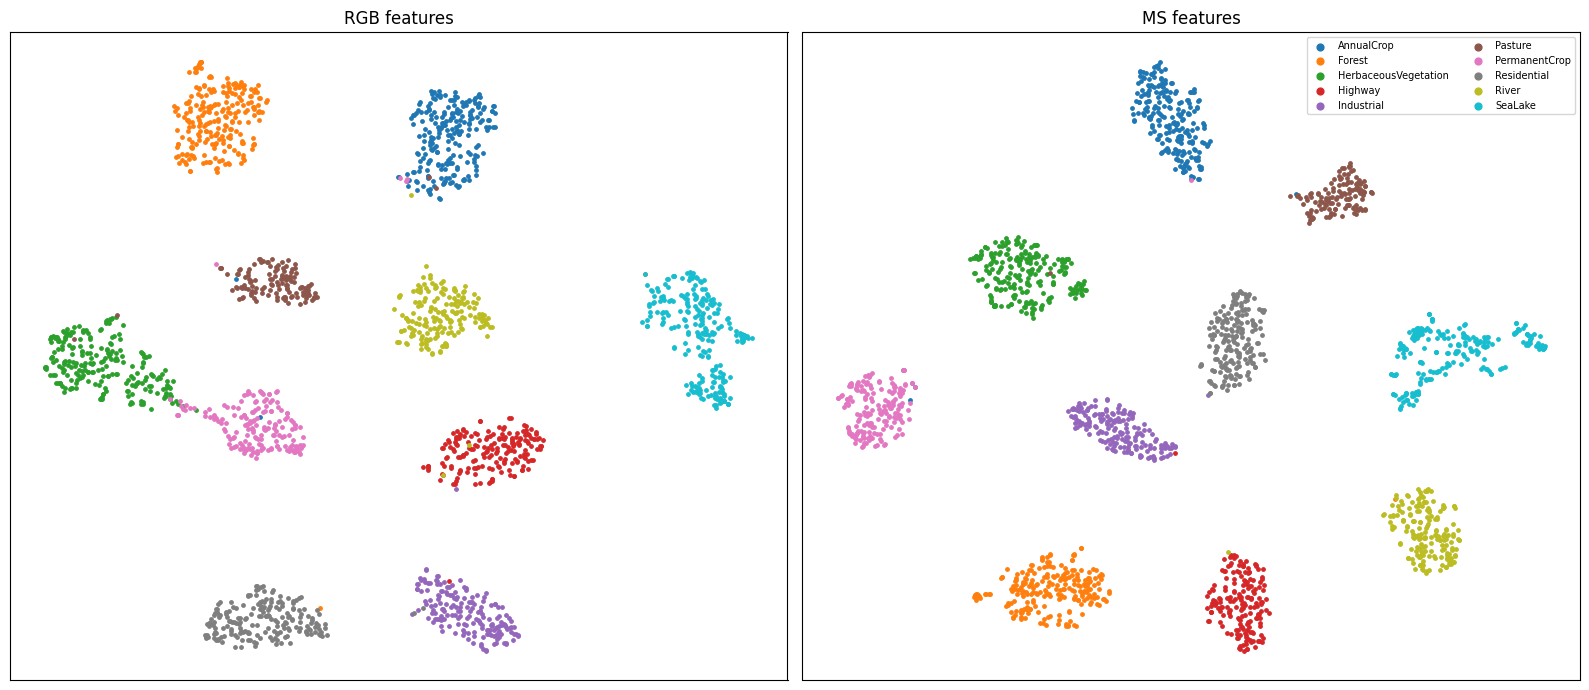

In [30]:
@torch.no_grad()
def extract_feats(model, loader):
    for mod in model.modules(): mod._forward_hooks.clear()
    feats, labels = [], []
    h = model.fc.register_forward_hook(lambda m, i, o: feats.append(i[0].detach().cpu()))
    model.eval()
    for x, y in tqdm(loader, leave=False):
        model(x.to(device)); labels.append(y)
    h.remove()
    return torch.cat(feats).numpy(), torch.cat(labels).numpy()

def tsne_panel(model, loader, title, ax, n=2000):
    f, lab = extract_feats(model, loader)
    if len(f) > n:
        idx = np.random.RandomState(0).choice(len(f), n, replace=False); f, lab = f[idx], lab[idx]
    emb = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(f)
    for i, c in enumerate(classes):
        m = lab == i; ax.scatter(emb[m, 0], emb[m, 1], s=6, label=c)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
tsne_panel(rgb_model, rgb_ld, "RGB features", ax[0])
tsne_panel(ms_model,  ms_ld,  "MS features",  ax[1])
ax[1].legend(fontsize=7, markerscale=2, ncol=2)
plt.tight_layout(); plt.savefig("tsne_rgb_vs_ms.png", dpi=150, bbox_inches="tight"); plt.show()

*Interpretation (t-SNE).* In RGB feature space the agriculture/vegetation classes
overlap into one region (matching their confusion); the multispectral model pushes
them into `__` (more / less) separated clusters. This is the representation-level
view of the same story: the extra bands give the network a feature space where the
hard classes become more linearly separable.

## 14. Summary (for the report)

- **2C** Both models reach ~98–99%; errors concentrate on AnnualCrop↔PermanentCrop
  and Pasture↔HerbaceousVegetation. (cm_rgb.png, cm_ms.png)
- **Comparison** MS improves overall accuracy and, crucially, the gain is
  localised to the spectrally-distinct confused pairs. (rgb_vs_ms_delta.png,
  confusion_diff.png)
- **2A** Grad-CAM/++ attention is on sensible structure for correct calls; dual-CAM
  shows failures stem from genuinely ambiguous appearance, not mislocalised
  attention.
- **2B** Occlusion and SHAP agree on band importance, with NIR/red-edge/SWIR
  ranking high — matching remote-sensing physics. Spectral signatures and NDVI/NDWI
  show *why* the confused classes confuse (overlapping curves / index ranges).
  (band_importance.png, spectral_signatures.png, ndvi_ndwi_by_class.png)
- **Synthesis** t-SNE shows MS separates the confused classes better in feature
  space. (tsne_rgb_vs_ms.png)

Saved figures (drop into the report): cm_rgb, cm_ms, rgb_vs_ms_delta,
confusion_diff, band_importance, spectral_signatures, ndvi_ndwi_by_class,
tsne_rgb_vs_ms.

